In [1]:
# ======================================================================
# CELL 1: Windows Local Setup (NVIDIA GPU) — YOLO Version
#
# Recommended:
# 1) Create a fresh Python 3.11 environment.
#    Example with conda:
#       conda create -n e3_win python=3.11 -y
#       conda activate e3_win
#
# 2) Install PyTorch using the current official Windows + CUDA command
#    from the PyTorch "Get Started" page, then the remaining deps:
#       pip install gymnasium[atari] ale-py numpy pandas matplotlib scipy scikit-learn jupyter ipykernel
#       pip install ultralytics           # <-- YOLOv8 dependency
#
# 3) Optional: register this environment as a Jupyter kernel
#       python -m ipykernel install --user --name e3_win --display-name "E3 Windows GPU"
#
# 4) Open this notebook and run cells from top to bottom.
#
# Notes:
# - This notebook targets local Windows machines with an NVIDIA GPU.
# - The first YOLO load will download the pretrained COCO weights file
#   (e.g. `yolov8n.pt`, ~6 MB) into the current working directory.
# - This version uses the YOLOv8 backbone (layers 0-6) in place of
#   ResNet-18 as the frozen visual encoder.
# ======================================================================

print("Windows GPU notebook loaded (E3: Frozen YOLOv8). "
      "Make sure your CUDA-enabled PyTorch build and `ultralytics` are installed.")


Windows GPU notebook loaded (E3: Frozen YOLOv8). Make sure your CUDA-enabled PyTorch build and `ultralytics` are installed.


In [2]:
# ======================================================================
# CELL 2: Imports, Constants, Paths, and Device Selection
# ======================================================================

from pathlib import Path
import os
import sys
import time
import json
import math
import random
import platform
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions.categorical import Categorical

# YOLO import (replaces torchvision ResNet in E2)
from ultralytics import YOLO

import gymnasium as gym
import ale_py
from gymnasium.wrappers import AtariPreprocessing, RecordEpisodeStatistics
try:
    from gymnasium.wrappers import FrameStackObservation as FrameStackWrapper
except ImportError:
    from gymnasium.wrappers import FrameStack as FrameStackWrapper

gym.register_envs(ale_py)

# -----------------------------
# Experiment configuration
# -----------------------------
ENV_ID = "PongNoFrameskip-v4"
FRAME_SKIP = 4
NUM_STACK = 4

SWEEP_SEED = 0
FINAL_SEEDS = [0, 1, 2, 3, 4]

LR_CANDIDATES = [1e-4, 2.5e-4, 1e-3]
CLIP_CANDIDATES = [0.1, 0.2]

SWEEP_TOTAL_TIMESTEPS = 1_000_000
FINAL_TOTAL_TIMESTEPS = 2_000_000

# Use 8 * 125 = 1000 steps/update so both 1M and 2M are exactly divisible.
NUM_ENVS = 8
NUM_STEPS = 125
NUM_MINIBATCHES = 4

GAMMA = 0.99
GAE_LAMBDA = 0.95
UPDATE_EPOCHS = 4
ENT_COEF = 0.01
VF_COEF = 0.5
MAX_GRAD_NORM = 0.5
TARGET_KL = None

# -----------------------------
# YOLO-specific configuration
# -----------------------------
# Model size:
#   'n' nano   (~3.2M backbone params, width=0.25)  <-- recommended default
#   's' small  (~11M backbone params, width=0.50)
#   'm' medium (~26M backbone params, width=0.75)
YOLO_MODEL_SIZE = 'n'

# Which prefix of `yolo.model.model` to use as the encoder.
# Layer layout for YOLOv8 (all use f=-1 so nn.Sequential is safe):
#   0  Conv s2   (P1/2)
#   1  Conv s2   (P2/4)
#   2  C2f
#   3  Conv s2   (P3/8)
#   4  C2f
#   5  Conv s2   (P4/16)
#   6  C2f                <-- we stop here
#   7  Conv s2   (P5/32)  <-- skipped
#   8  C2f                <-- skipped
#   9  SPPF              <-- skipped (had destroyed spatial info in previous attempt)
#
# With input 84x84, output after layer 6 is (128, 6, 6) for YOLOv8n.
# 4 frames * 128 * 6 * 6 = 18,432  which exactly matches E2's ResNet-18.
YOLO_BACKBONE_END = 7     # means layers[:7] -> layers 0..6 inclusive
YOLO_INPUT_SIZE   = 84    # no resize; keep directly comparable to E1/E2

PREFERRED_ACCELERATOR = 'cuda'
PROJECT_DIRNAME = 'E3_experiment_windows_gpu_YOLO'

assert (NUM_ENVS * NUM_STEPS) == 1000
assert SWEEP_TOTAL_TIMESTEPS % (NUM_ENVS * NUM_STEPS) == 0
assert FINAL_TOTAL_TIMESTEPS % (NUM_ENVS * NUM_STEPS) == 0

project_root = Path(f"./{PROJECT_DIRNAME}")
for sub in ["checkpoints", "logs", "plots", "tables"]:
    (project_root / "outputs" / sub).mkdir(parents=True, exist_ok=True)

def get_runtime_device(preferred=PREFERRED_ACCELERATOR):
    if preferred == "cuda":
        if torch.cuda.is_available():
            return torch.device("cuda")
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            return torch.device("mps")
        return torch.device("cpu")
    if preferred == "mps":
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            return torch.device("mps")
        if torch.cuda.is_available():
            return torch.device("cuda")
        return torch.device("cpu")
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

device = get_runtime_device()

print("Platform:", platform.platform())
print("Python:", sys.version.split()[0])
print("Torch:", torch.__version__)
print("Preferred accelerator:", PREFERRED_ACCELERATOR)
print("Resolved device:", device)
print(f"YOLO size: yolov8{YOLO_MODEL_SIZE}.pt  (backbone layers [:{YOLO_BACKBONE_END}])")

if device.type == "cuda":
    print("CUDA available:", torch.cuda.is_available())
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2), "GB")
elif device.type == "mps":
    print("MPS available:", torch.backends.mps.is_available())
    print("Apple Metal backend is active.")
else:
    print("Running on CPU.")

print("Project root:", project_root.resolve())


Platform: Windows-10-10.0.26200-SP0
Python: 3.11.15
Torch: 2.12.0.dev20260327+cu128
Preferred accelerator: cuda
Resolved device: cuda
YOLO size: yolov8n.pt  (backbone layers [:7])
CUDA available: True
GPU: NVIDIA GeForce RTX 5070 Laptop GPU
VRAM: 7.96 GB
Project root: C:\Users\zhang\Desktop\ELG5214\E3\E3_experiment_windows_gpu_YOLO


In [3]:
# ======================================================================
# CELL 3: Utility Functions and Environment Construction
# (identical to E2 / E1 for direct comparability)
# ======================================================================

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if hasattr(torch.backends, "cudnn"):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


def safe_empty_cache():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    if hasattr(torch, "mps") and hasattr(torch.mps, "empty_cache"):
        try:
            torch.mps.empty_cache()
        except Exception:
            pass


class FireResetWrapper(gym.Wrapper):
    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        try:
            meanings = self.unwrapped.get_action_meanings()
            if "FIRE" in meanings:
                fire_action = meanings.index("FIRE")
                obs, _, terminated, truncated, info = self.env.step(fire_action)
                if terminated or truncated:
                    obs, info = self.env.reset(**kwargs)
        except Exception:
            pass
        return obs, info


def make_env(seed: int, idx: int):
    def thunk():
        env = gym.make(ENV_ID, render_mode=None, frameskip=1)
        env = AtariPreprocessing(
            env,
            frame_skip=FRAME_SKIP,
            screen_size=84,
            grayscale_obs=True,
            scale_obs=False,
        )
        env = FrameStackWrapper(env, NUM_STACK)
        env = FireResetWrapper(env)
        env = RecordEpisodeStatistics(env)

        try:
            env.action_space.seed(seed + idx)
            env.observation_space.seed(seed + idx)
        except Exception:
            pass
        return env
    return thunk


def load_checkpoint_state_dict(path, map_location):
    try:
        return torch.load(path, map_location=map_location, weights_only=True)
    except TypeError:
        return torch.load(path, map_location=map_location)


test_env = make_env(0, 0)()
obs, _ = test_env.reset(seed=0)
obs_np = np.asarray(obs)

print("ENV_ID:", ENV_ID)
print("obs shape:", obs_np.shape, "| dtype:", obs_np.dtype)
print("action_dim:", test_env.action_space.n)
print("action meanings:", test_env.unwrapped.get_action_meanings())

action_dim = test_env.action_space.n
test_env.close()


ENV_ID: PongNoFrameskip-v4
obs shape: (4, 84, 84) | dtype: uint8
action_dim: 6
action meanings: ['NOOP', 'FIRE', 'RIGHT', 'LEFT', 'RIGHTFIRE', 'LEFTFIRE']


In [4]:
# ======================================================================
# CELL 4: Model Definition — Frozen YOLOv8 Backbone (layers 0-6) + PPO Agent
#
# Architecture (intentionally identical shape to E2's ResNet-18 head):
#   FrozenFramewiseYOLOBackbone:
#     - YOLOv8n (COCO pretrained) backbone, layers [0..6], ALL FROZEN
#     - Each of 4 stacked frames processed independently
#     - Grayscale -> 3-channel repeat -> ImageNet normalization
#     - Output: (B, 4, 128, 6, 6)  -- spatial info preserved, no SPPF
#
#   E3Agent:
#     - Flatten: 4 * 128 * 6 * 6 = 18,432  (exactly matches E2)
#     - Projection: Linear(18432, 512) + ReLU
#     - Shared:     Linear(512, 512) + ReLU
#     - Actor:      Linear(512, action_dim)
#     - Critic:     Linear(512, 1)
#
# WHY layers [:7] and NOT [:10]:
#   The previous YOLO attempt used layers [:10], which ENDS at the SPPF
#   module (layer 9). On a 3x3 feature map SPPF's stacked 5x5 pools act
#   globally and erase positional information — the agent literally could
#   not tell where the ball was. Stopping at layer 6 (C2f after the P4
#   stride-16 downsample) leaves a 6x6 spatial grid on an 84x84 input,
#   which preserves enough position granularity for Pong.
# ======================================================================

class FrozenFramewiseYOLOBackbone(nn.Module):
    """Frozen YOLOv8 backbone (layers 0..end_idx-1) used as a fixed encoder."""

    def __init__(self, model_size: str = YOLO_MODEL_SIZE, end_idx: int = YOLO_BACKBONE_END):
        super().__init__()

        # 1) Load pretrained YOLO and grab its internal ModuleList
        yolo = YOLO(f"yolov8{model_size}.pt")
        full_layers = list(yolo.model.model)

        # 2) Sanity check: in YOLOv8, backbone layers 0..9 all use f=-1,
        #    which means nn.Sequential(*[:end_idx]) is safe as long as
        #    end_idx <= 10 (i.e. we don't pull in neck layers that need
        #    multi-source concatenations).
        assert 3 <= end_idx <= 10, (
            f"YOLO_BACKBONE_END must be in [3, 10]; got {end_idx}. "
            "Neck layers (10+) use skip connections incompatible with nn.Sequential."
        )
        self.backbone = nn.Sequential(*full_layers[:end_idx])

        # 3) Freeze all parameters and drop BN updates
        for p in self.backbone.parameters():
            p.requires_grad = False
        self.backbone.eval()

        # 4) ImageNet normalization (same mean/std YOLO itself uses)
        mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
        std  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
        self.register_buffer("mean", mean)
        self.register_buffer("std",  std)

        # 5) Compute and remember output shape for the given input size
        with torch.no_grad():
            dummy = torch.zeros(1, 3, YOLO_INPUT_SIZE, YOLO_INPUT_SIZE)
            out = self.backbone(dummy)
        self.out_channels = out.shape[1]
        self.out_h = out.shape[2]
        self.out_w = out.shape[3]
        self.out_dim = self.out_channels * self.out_h * self.out_w

        print(
            f"YOLO backbone (yolov8{model_size}, layers[:{end_idx}]) "
            f"output: C={self.out_channels}, H={self.out_h}, W={self.out_w} "
            f"-> per-frame dim = {self.out_dim}"
        )

    def forward(self, obs):
        """
        obs: (B, NUM_STACK, 84, 84) uint8
        returns: (B, NUM_STACK, C, H, W) float
        """
        B = obs.shape[0]
        x = obs.float() / 255.0
        # per-frame: grayscale -> 3-channel repeat
        x = x.reshape(B * NUM_STACK, 1, YOLO_INPUT_SIZE, YOLO_INPUT_SIZE).repeat(1, 3, 1, 1)
        # ImageNet normalization
        x = (x - self.mean) / self.std

        with torch.no_grad():
            z = self.backbone(x)                # (B*4, C, H, W)

        z = z.view(B, NUM_STACK, self.out_channels, self.out_h, self.out_w)
        return z


class E3Agent(nn.Module):
    """PPO agent with a frozen YOLOv8 backbone encoder."""

    def __init__(self, action_dim):
        super().__init__()
        self.encoder = FrozenFramewiseYOLOBackbone()

        # Flattened dim = 4 frames * C * H * W
        flat_dim = NUM_STACK * self.encoder.out_dim
        self._flat_dim = flat_dim

        self.projection = nn.Sequential(
            nn.Linear(flat_dim, 512),
            nn.ReLU(),
        )
        self.shared = nn.Sequential(
            nn.Linear(512, 512),
            nn.ReLU(),
        )
        self.actor = nn.Linear(512, action_dim)
        self.critic = nn.Linear(512, 1)

        print(f"E3Agent: flat_dim={flat_dim} -> 512 -> 512 -> (actor={action_dim}, critic=1)")

    def forward_features(self, obs):
        B = obs.shape[0]
        z = self.encoder(obs)              # (B, 4, C, H, W)
        z = z.reshape(B, -1)               # (B, flat_dim)
        h = self.projection(z)             # (B, 512)
        h = self.shared(h)                 # (B, 512)
        return h

    def get_value(self, obs):
        return self.critic(self.forward_features(obs)).squeeze(-1)

    def get_action_and_value(self, obs, action=None):
        h = self.forward_features(obs)
        logits = self.actor(h)
        dist = Categorical(logits=logits)
        if action is None:
            action = dist.sample()
        value = self.critic(h).squeeze(-1)
        return action, dist.log_prob(action), dist.entropy(), value


In [5]:
# ======================================================================
# CELL 5: Smoke Test — Model Shapes and Parameter Counts
# ======================================================================

set_seed(0)
_agent = E3Agent(action_dim=action_dim).to(device)
_dummy = torch.randint(0, 256, (8, NUM_STACK, 84, 84), dtype=torch.uint8, device=device)

a, lp, ent, v = _agent.get_action_and_value(_dummy)
print("action:", a.shape, "| logprob:", lp.shape, "| entropy:", ent.shape, "| value:", v.shape)

total_p = sum(p.numel() for p in _agent.parameters())
train_p = sum(p.numel() for p in _agent.parameters() if p.requires_grad)

print(f"Total params:     {total_p:>12,}")
print(f"Trainable params: {train_p:>12,}")
print(f"Frozen params:    {total_p - train_p:>12,}")

# Cross-check: E2's ResNet-18 head has flat_dim = 18,432.
# With YOLOv8n layers[:7] and 84x84 input we should get exactly that too.
expected_flat = 4 * 128 * 6 * 6
if _agent._flat_dim == expected_flat:
    print(f"[OK] flat_dim = {_agent._flat_dim} matches E2 exactly (4*128*6*6).")
else:
    print(f"[NOTE] flat_dim = {_agent._flat_dim} (E2 reference is {expected_flat}). "
          "Different YOLO size will produce a different flat_dim — fine, just different.")

if device.type == "cuda":
    print(f"VRAM used:     {torch.cuda.memory_allocated()/1024**2:>10.0f} MB")
    print(f"VRAM reserved: {torch.cuda.memory_reserved()/1024**2:>10.0f} MB")

del _agent, _dummy
safe_empty_cache()


YOLO backbone (yolov8n, layers[:7]) output: C=128, H=6, W=6 -> per-frame dim = 4608
E3Agent: flat_dim=18432 -> 512 -> 512 -> (actor=6, critic=1)
action: torch.Size([8]) | logprob: torch.Size([8]) | entropy: torch.Size([8]) | value: torch.Size([8])
Total params:       10,056,279
Trainable params:    9,703,943
Frozen params:         352,336
[OK] flat_dim = 18432 matches E2 exactly (4*128*6*6).
VRAM used:             71 MB
VRAM reserved:         98 MB


In [6]:
# ======================================================================
# CELL 6: PPO Training Function
# (Identical PPO logic to E2 — only the agent class differs.)
# ======================================================================

def train_e3(agent, optimizer, config):
    set_seed(config["seed"])
    dev = torch.device(config["device"])
    agent.train()
    agent.encoder.backbone.eval()   # keep BN running-stats fixed on frozen backbone

    ckpt_dir = project_root / "outputs" / "checkpoints" / config["run_name"]
    log_dir  = project_root / "outputs" / "logs"        / config["run_name"]
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    log_dir.mkdir(parents=True, exist_ok=True)

    NE = config["num_envs"]
    NS = config["num_steps"]
    BS = NE * NS
    assert config["total_timesteps"] % BS == 0, "total_timesteps must be divisible by num_envs*num_steps"
    MBS = BS // config["num_minibatches"]
    assert BS % config["num_minibatches"] == 0, "Batch size must be divisible by num_minibatches"
    NU = config["total_timesteps"] // BS

    envs = gym.vector.SyncVectorEnv([make_env(config["seed"], i) for i in range(NE)])
    obs, _ = envs.reset(seed=[config["seed"] + i for i in range(NE)])

    ep_ret = np.zeros(NE, dtype=np.float32)
    recent = deque(maxlen=20)
    all_ep_returns = []
    log_rows = []
    global_step = 0
    best = -1e9
    t0 = time.time()

    for upd in range(1, NU + 1):
        if config.get("anneal_lr", False):
            frac = 1.0 - (upd - 1.0) / NU
            optimizer.param_groups[0]["lr"] = frac * config["learning_rate"]

        ob = torch.zeros((NS, NE, NUM_STACK, 84, 84), dtype=torch.uint8, device=dev)
        ac = torch.zeros((NS, NE), dtype=torch.long,   device=dev)
        lp = torch.zeros((NS, NE), dtype=torch.float32, device=dev)
        rw = torch.zeros((NS, NE), dtype=torch.float32, device=dev)
        dn = torch.zeros((NS, NE), dtype=torch.float32, device=dev)
        vl = torch.zeros((NS, NE), dtype=torch.float32, device=dev)

        for t in range(NS):
            global_step += NE
            obs_t = torch.as_tensor(np.asarray(obs), dtype=torch.uint8, device=dev)
            ob[t] = obs_t

            with torch.no_grad():
                a, l, e, v = agent.get_action_and_value(obs_t)

            ac[t] = a
            lp[t] = l
            vl[t] = v

            next_obs, rew, term, trunc, info = envs.step(a.detach().cpu().numpy())
            done = np.logical_or(term, trunc)

            rw[t] = torch.as_tensor(rew,  dtype=torch.float32, device=dev)
            dn[t] = torch.as_tensor(done, dtype=torch.float32, device=dev)

            ep_ret += rew.astype(np.float32)
            for i in range(NE):
                if done[i]:
                    ret_val = float(ep_ret[i])
                    recent.append(ret_val)
                    all_ep_returns.append(ret_val)
                    if ret_val > best:
                        best = ret_val
                        torch.save(agent.state_dict(), ckpt_dir / "best.pt")
                    ep_ret[i] = 0.0

            obs = next_obs

        with torch.no_grad():
            next_value = agent.get_value(torch.as_tensor(np.asarray(obs), dtype=torch.uint8, device=dev))

        adv = torch.zeros_like(rw)
        lastgaelam = torch.zeros(NE, dtype=torch.float32, device=dev)

        for t in reversed(range(NS)):
            next_non_terminal = 1.0 - dn[t]
            next_values = next_value if t == NS - 1 else vl[t + 1]
            delta = rw[t] + config["gamma"] * next_values * next_non_terminal - vl[t]
            lastgaelam = delta + config["gamma"] * config["gae_lambda"] * next_non_terminal * lastgaelam
            adv[t] = lastgaelam

        ret = adv + vl

        b_obs  = ob.reshape((-1, NUM_STACK, 84, 84))
        b_act  = ac.reshape(-1)
        b_logp = lp.reshape(-1)
        b_adv  = adv.reshape(-1)
        b_ret  = ret.reshape(-1)
        b_val  = vl.reshape(-1)

        b_adv = (b_adv - b_adv.mean()) / (b_adv.std() + 1e-8)

        batch_idx = np.arange(BS)
        clipfracs = []
        approx_kl    = torch.tensor(0.0, device=dev)
        pg_loss      = torch.tensor(0.0, device=dev)
        v_loss       = torch.tensor(0.0, device=dev)
        entropy_loss = torch.tensor(0.0, device=dev)

        early_stop = False
        for epoch in range(config["update_epochs"]):
            np.random.shuffle(batch_idx)
            for start in range(0, BS, MBS):
                mb_idx = batch_idx[start:start + MBS]
                _, newlogp, entropy, newvalue = agent.get_action_and_value(b_obs[mb_idx], b_act[mb_idx])

                logratio = newlogp - b_logp[mb_idx]
                ratio = logratio.exp()

                with torch.no_grad():
                    approx_kl = ((ratio - 1.0) - logratio).mean()
                    clipfracs.append(((ratio - 1.0).abs() > config["clip_coef"]).float().mean().item())

                mb_adv = b_adv[mb_idx]
                pg_loss = torch.max(
                    -mb_adv * ratio,
                    -mb_adv * torch.clamp(ratio, 1 - config["clip_coef"], 1 + config["clip_coef"]),
                ).mean()

                v_loss_unclipped = (newvalue - b_ret[mb_idx]) ** 2
                v_clipped = b_val[mb_idx] + torch.clamp(
                    newvalue - b_val[mb_idx],
                    -config["clip_coef"],
                    config["clip_coef"],
                )
                v_loss_clipped = (v_clipped - b_ret[mb_idx]) ** 2
                v_loss = 0.5 * torch.max(v_loss_unclipped, v_loss_clipped).mean()

                entropy_loss = entropy.mean()
                loss = pg_loss - config["ent_coef"] * entropy_loss + config["vf_coef"] * v_loss

                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    [p for p in agent.parameters() if p.requires_grad],
                    config["max_grad_norm"],
                )
                optimizer.step()
                agent.encoder.backbone.eval()   # re-enforce eval mode on frozen backbone

                if config["target_kl"] is not None and approx_kl > config["target_kl"]:
                    early_stop = True
                    break
            if early_stop:
                break

        if upd % config.get("save_every_updates", 200) == 0:
            torch.save(agent.state_dict(), ckpt_dir / f"ckpt_{upd}.pt")

        elapsed = time.time() - t0
        sps = int(global_step / elapsed) if elapsed > 0 else 0

        row = {
            "update": upd,
            "global_step": global_step,
            "lr": float(optimizer.param_groups[0]["lr"]),
            "pg_loss": float(pg_loss.item()),
            "v_loss": float(v_loss.item()),
            "entropy": float(entropy_loss.item()),
            "approx_kl": float(approx_kl.item()),
            "clipfrac": float(np.mean(clipfracs)) if clipfracs else 0.0,
            "recent_return_mean": float(np.mean(recent)) if recent else np.nan,
            "recent_return_std":  float(np.std(recent))  if recent else np.nan,
            "best_return": float(best),
            "sps": sps,
            "elapsed_sec": elapsed,
        }
        log_rows.append(row)

        if upd % 20 == 0 or upd == 1:
            print(
                f"upd={upd:04d}/{NU} "
                f"step={global_step:,} "
                f"ret={row['recent_return_mean']:.2f} "
                f"best={best:.0f} "
                f"pg={row['pg_loss']:.4f} "
                f"ent={row['entropy']:.4f} "
                f"sps={sps}"
            )

    torch.save(agent.state_dict(), ckpt_dir / "final.pt")

    log_df = pd.DataFrame(log_rows)
    log_df.to_csv(log_dir / "train_log.csv", index=False)

    summary = {
        "run_name": config["run_name"],
        "seed": config["seed"],
        "env_id": ENV_ID,
        "total_timesteps": config["total_timesteps"],
        "effective_total_timesteps": int(global_step),
        "learning_rate": config["learning_rate"],
        "clip_coef": config["clip_coef"],
        "best_episode_return": float(best),
        "final_recent_return_mean": float(np.mean(recent)) if recent else None,
        "final_recent_return_std":  float(np.std(recent))  if recent else None,
        "num_episodes_finished": len(all_ep_returns),
        "wall_clock_sec": time.time() - t0,
        "mean_sps": float(log_df["sps"].mean()) if len(log_df) > 0 else 0.0,
        "yolo_model_size": YOLO_MODEL_SIZE,
        "yolo_backbone_end": YOLO_BACKBONE_END,
    }

    with open(log_dir / "summary.json", "w") as f:
        json.dump(summary, f, indent=2)

    envs.close()
    print(
        f"\nDone: best={best}, "
        f"mean={summary['final_recent_return_mean']}, "
        f"steps={global_step:,}, "
        f"sps={summary['mean_sps']:.0f}"
    )
    return log_df, summary


In [7]:
# ======================================================================
# CELL 7: Hyperparameter Sweep — single seed, 1M steps
# Grid: 3 learning rates × 2 PPO clip values = 6 runs
# ======================================================================

sweep_results = []

for lr in LR_CANDIDATES:
    for clip in CLIP_CANDIDATES:
        tag = f"sweep_seed{SWEEP_SEED}_lr{lr}_clip{clip}"
        print(f"\n{'='*68}\nSweep: seed={SWEEP_SEED}, LR={lr}, clip={clip}\n{'='*68}\n")

        cfg = {
            "run_name": tag,
            "seed": SWEEP_SEED,
            "total_timesteps": SWEEP_TOTAL_TIMESTEPS,
            "num_envs": NUM_ENVS,
            "num_steps": NUM_STEPS,
            "gamma": GAMMA,
            "gae_lambda": GAE_LAMBDA,
            "learning_rate": lr,
            "anneal_lr": False,
            "clip_coef": clip,
            "update_epochs": UPDATE_EPOCHS,
            "num_minibatches": NUM_MINIBATCHES,
            "ent_coef": ENT_COEF,
            "vf_coef": VF_COEF,
            "max_grad_norm": MAX_GRAD_NORM,
            "target_kl": TARGET_KL,
            "save_every_updates": 250,
            "device": str(device),
        }

        set_seed(SWEEP_SEED)
        ag = E3Agent(action_dim=action_dim).to(device)
        op = torch.optim.Adam([p for p in ag.parameters() if p.requires_grad], lr=lr, eps=1e-5)

        _, sm = train_e3(ag, op, cfg)

        sweep_results.append({
            "seed": SWEEP_SEED,
            "lr": lr,
            "clip_coef": clip,
            "best_return": sm["best_episode_return"],
            "final_mean":  sm["final_recent_return_mean"],
            "final_std":   sm["final_recent_return_std"],
            "mean_sps":    sm["mean_sps"],
        })

        del ag, op
        safe_empty_cache()

sweep_df = (
    pd.DataFrame(sweep_results)
    .sort_values(["final_mean", "best_return"], ascending=[False, False])
    .reset_index(drop=True)
)
sweep_df.to_csv(project_root / "outputs" / "tables" / "hp_sweep.csv", index=False)

print("\n" + "="*68 + "\nSweep Results\n" + "="*68)
print(sweep_df.to_string(index=False))



Sweep: seed=0, LR=0.0001, clip=0.1

YOLO backbone (yolov8n, layers[:7]) output: C=128, H=6, W=6 -> per-frame dim = 4608
E3Agent: flat_dim=18432 -> 512 -> 512 -> (actor=6, critic=1)
upd=0001/1000 step=1,000 ret=nan best=-1000000000 pg=-0.0292 ent=1.7893 sps=570
upd=0020/1000 step=20,000 ret=-20.31 best=-19 pg=-0.0098 ent=1.7629 sps=733
upd=0040/1000 step=40,000 ret=-20.80 best=-19 pg=-0.0669 ent=1.7501 sps=719
upd=0060/1000 step=60,000 ret=-20.70 best=-19 pg=0.0002 ent=1.6777 sps=708
upd=0080/1000 step=80,000 ret=-20.60 best=-19 pg=0.0297 ent=1.6206 sps=728
upd=0100/1000 step=100,000 ret=-20.25 best=-19 pg=-0.0166 ent=1.6147 sps=729
upd=0120/1000 step=120,000 ret=-20.25 best=-19 pg=0.0695 ent=1.6109 sps=729
upd=0140/1000 step=140,000 ret=-20.05 best=-18 pg=0.0820 ent=1.5928 sps=737
upd=0160/1000 step=160,000 ret=-20.35 best=-18 pg=-0.0669 ent=1.5866 sps=738
upd=0180/1000 step=180,000 ret=-19.85 best=-17 pg=0.0295 ent=1.5593 sps=735
upd=0200/1000 step=200,000 ret=-19.45 best=-16 pg=0.06

In [8]:
# ======================================================================
# CELL 8: Select Best Hyperparameters
# ======================================================================

# If running in a new session:
# sweep_df = pd.read_csv(project_root / "outputs" / "tables" / "hp_sweep.csv")
# sweep_df = sweep_df.sort_values(["final_mean", "best_return"], ascending=[False, False]).reset_index(drop=True)

best_row = sweep_df.iloc[0]
BEST_LR = float(best_row["lr"])
BEST_CLIP = float(best_row["clip_coef"])

print(
    f"Best config -> LR={BEST_LR}, clip={BEST_CLIP}, "
    f"final_mean={best_row['final_mean']}, best_return={best_row['best_return']}"
)


Best config -> LR=0.001, clip=0.2, final_mean=-3.75, best_return=20.0


In [9]:
# ======================================================================
# CELL 9: Final Runs — best hyperparameters × 5 seeds, 2M steps
# Seeds: 0, 1, 2, 3, 4
# ======================================================================

all_logs = {}
all_summaries = {}

for seed in FINAL_SEEDS:
    print(f"\n{'='*68}\nFinal run: seed={seed}, LR={BEST_LR}, clip={BEST_CLIP}\n{'='*68}\n")

    cfg = {
        "run_name": f"E3_final_seed{seed}",
        "seed": seed,
        "total_timesteps": FINAL_TOTAL_TIMESTEPS,
        "num_envs": NUM_ENVS,
        "num_steps": NUM_STEPS,
        "gamma": GAMMA,
        "gae_lambda": GAE_LAMBDA,
        "learning_rate": BEST_LR,
        "anneal_lr": False,
        "clip_coef": BEST_CLIP,
        "update_epochs": UPDATE_EPOCHS,
        "num_minibatches": NUM_MINIBATCHES,
        "ent_coef": ENT_COEF,
        "vf_coef": VF_COEF,
        "max_grad_norm": MAX_GRAD_NORM,
        "target_kl": TARGET_KL,
        "save_every_updates": 500,
        "device": str(device),
    }

    set_seed(seed)
    ag = E3Agent(action_dim=action_dim).to(device)
    op = torch.optim.Adam([p for p in ag.parameters() if p.requires_grad], lr=BEST_LR, eps=1e-5)

    log_df, summary = train_e3(ag, op, cfg)
    all_logs[seed] = log_df
    all_summaries[seed] = summary

    print(
        f"Seed {seed}: "
        f"best={summary['best_episode_return']}, "
        f"final_mean={summary['final_recent_return_mean']:.2f}"
    )

    del ag, op
    safe_empty_cache()

with open(project_root / "outputs" / "tables" / "final_summaries.json", "w") as f:
    json.dump({str(k): v for k, v in all_summaries.items()}, f, indent=2)

means = [s["final_recent_return_mean"] for s in all_summaries.values() if s["final_recent_return_mean"] is not None]
bests = [s["best_episode_return"] for s in all_summaries.values()]
spss  = [s["mean_sps"] for s in all_summaries.values()]

print(f"\n{'='*68}\nAll Seeds Summary\n{'='*68}")
print(f"Final mean return: {np.mean(means):.2f} ± {np.std(means)/np.sqrt(len(means)):.2f} (SE)")
print(f"Best return range: [{min(bests):.0f}, {max(bests):.0f}]")
print(f"Throughput (SPS):  {np.mean(spss):.0f} ± {np.std(spss):.0f}")



Final run: seed=0, LR=0.001, clip=0.2

YOLO backbone (yolov8n, layers[:7]) output: C=128, H=6, W=6 -> per-frame dim = 4608
E3Agent: flat_dim=18432 -> 512 -> 512 -> (actor=6, critic=1)
upd=0001/2000 step=1,000 ret=nan best=-1000000000 pg=0.2788 ent=1.0570 sps=752
upd=0020/2000 step=20,000 ret=-21.00 best=-21 pg=0.0790 ent=0.0008 sps=714
upd=0040/2000 step=40,000 ret=-21.00 best=-21 pg=-0.0224 ent=0.4128 sps=694
upd=0060/2000 step=60,000 ret=-21.00 best=-21 pg=-0.0743 ent=0.8262 sps=685
upd=0080/2000 step=80,000 ret=-20.95 best=-20 pg=0.0362 ent=0.6155 sps=688
upd=0100/2000 step=100,000 ret=-20.90 best=-20 pg=-0.0354 ent=0.9055 sps=687
upd=0120/2000 step=120,000 ret=-20.55 best=-19 pg=0.0414 ent=1.1586 sps=672
upd=0140/2000 step=140,000 ret=-19.80 best=-17 pg=0.0725 ent=0.8513 sps=674
upd=0160/2000 step=160,000 ret=-19.60 best=-16 pg=0.0184 ent=1.0224 sps=681
upd=0180/2000 step=180,000 ret=-19.45 best=-14 pg=0.0619 ent=0.9471 sps=688
upd=0200/2000 step=200,000 ret=-17.65 best=-14 pg=0.0

In [10]:
# ======================================================================
# CELL 10: Reload Logs From Disk (optional, only for a fresh session)
# ======================================================================

# all_logs = {}
# all_summaries = {}
# for seed in FINAL_SEEDS:
#     log_path = project_root / "outputs" / "logs" / f"E3_final_seed{seed}" / "train_log.csv"
#     summary_path = project_root / "outputs" / "logs" / f"E3_final_seed{seed}" / "summary.json"
#     if log_path.exists() and summary_path.exists():
#         all_logs[seed] = pd.read_csv(log_path)
#         with open(summary_path) as f:
#             all_summaries[seed] = json.load(f)
#         print(f"Loaded seed {seed}")
#
# print(f"Loaded {len(all_logs)} seeds")
# BEST_LR   = all_summaries[FINAL_SEEDS[0]]["learning_rate"]
# BEST_CLIP = all_summaries[FINAL_SEEDS[0]]["clip_coef"]


C:\Users\zhang\AppData\Local\Temp\ipykernel_65092\3299358915.py:27: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(mat, axis=0)
c:\Users\zhang\anaconda3\envs\e2exp\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Saved -> E3_experiment_windows_gpu_YOLO\outputs\plots\e3_return_curve.png


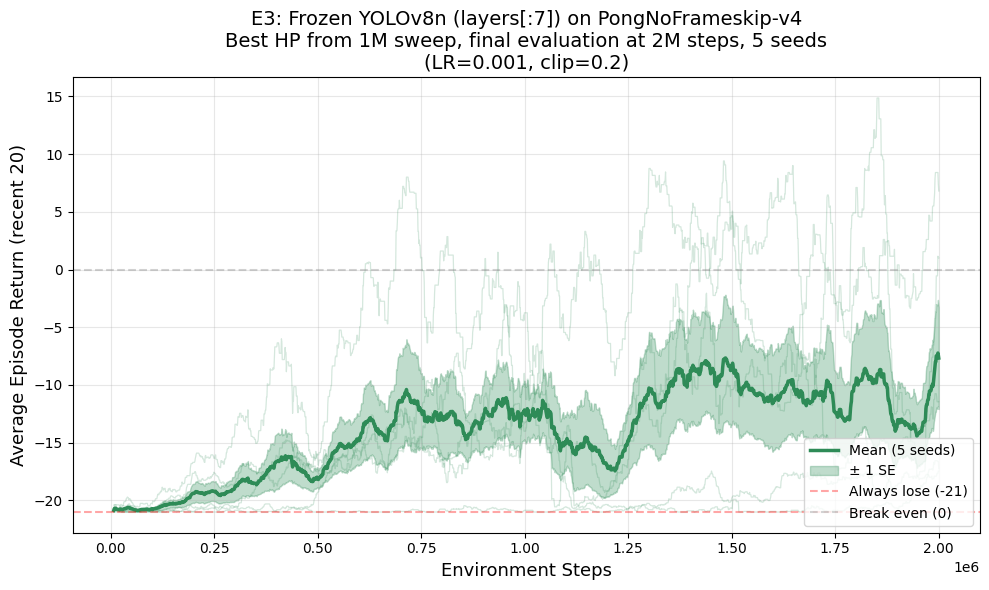

In [11]:
# ======================================================================
# CELL 11: Plot 1 — Reward Curve
# mean ± SE across 5 seeds, plus faint per-seed traces
# ======================================================================

def plot_return_curves(all_logs, title, save_path=None):
    fig, ax = plt.subplots(figsize=(10, 6))
    seeds = sorted(all_logs.keys())

    min_len = min(len(all_logs[s]) for s in seeds)
    if len({len(all_logs[s]) for s in seeds}) != 1:
        print("Warning: log lengths differ; truncating all runs to the shortest length.")

    for seed in seeds:
        df = all_logs[seed].iloc[:min_len]
        ax.plot(
            df["global_step"],
            df["recent_return_mean"],
            alpha=0.20,
            linewidth=0.9,
            color="seagreen",
        )

    ref = all_logs[seeds[0]].iloc[:min_len]["global_step"].values
    mat = np.array([all_logs[s].iloc[:min_len]["recent_return_mean"].values for s in seeds])

    mean_curve = np.nanmean(mat, axis=0)
    se_curve   = np.nanstd(mat, axis=0) / np.sqrt(len(seeds))

    ax.plot(ref, mean_curve, linewidth=2.5, color="seagreen", label=f"Mean ({len(seeds)} seeds)")
    ax.fill_between(ref, mean_curve - se_curve, mean_curve + se_curve,
                    alpha=0.30, color="seagreen", label="± 1 SE")
    ax.axhline(-21, color="red",  linestyle="--", alpha=0.35, label="Always lose (-21)")
    ax.axhline(0,   color="gray", linestyle="--", alpha=0.35, label="Break even (0)")

    ax.set_xlabel("Environment Steps", fontsize=13)
    ax.set_ylabel("Average Episode Return (recent 20)", fontsize=13)
    ax.set_title(title, fontsize=14)
    ax.legend(fontsize=10, loc="lower right")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved -> {save_path}")

    plt.show()


plot_return_curves(
    all_logs,
    (
        f"E3: Frozen YOLOv8{YOLO_MODEL_SIZE} (layers[:{YOLO_BACKBONE_END}]) on {ENV_ID}\n"
        f"Best HP from 1M sweep, final evaluation at 2M steps, 5 seeds\n"
        f"(LR={BEST_LR}, clip={BEST_CLIP})"
    ),
    project_root / "outputs" / "plots" / "e3_return_curve.png",
)


In [12]:
# ======================================================================
# CELL 12: Sample Efficiency
# ======================================================================

def compute_sample_efficiency(all_logs, threshold_frac=0.70):
    seeds = sorted(all_logs.keys())
    min_return, max_return = -21.0, 21.0

    overall_best = max(all_logs[s]["recent_return_mean"].max() for s in seeds)
    norm_best = (overall_best - min_return) / (max_return - min_return)
    threshold = threshold_frac * norm_best * (max_return - min_return) + min_return

    print(f"Overall best mean return: {overall_best:.2f}")
    print(f"Threshold ({threshold_frac:.0%} of normalized best): {threshold:.2f}\n")

    results = {}
    for seed in seeds:
        df = all_logs[seed]
        reached = df[df["recent_return_mean"] >= threshold]
        if len(reached) > 0:
            step = int(reached.iloc[0]["global_step"])
            results[seed] = step
            print(f"Seed {seed}: reached {threshold:.2f} at step {step:,}")
        else:
            results[seed] = None
            print(f"Seed {seed}: never reached {threshold:.2f}")

    valid = [v for v in results.values() if v is not None]
    if valid:
        print(f"\nSample efficiency: {np.mean(valid):,.0f} ± {np.std(valid):,.0f} steps")
    else:
        print("\nNo seed reached the threshold.")

    return results


efficiency = compute_sample_efficiency(all_logs)


Overall best mean return: 14.85
Threshold (70% of normalized best): 4.10

Seed 0: reached 4.10 at step 1,290,000
Seed 1: reached 4.10 at step 1,976,000
Seed 2: never reached 4.10
Seed 3: reached 4.10 at step 693,000
Seed 4: never reached 4.10

Sample efficiency: 1,319,667 ± 524,202 steps


In [13]:
# ======================================================================
# CELL 13: Throughput Table
# ======================================================================

print(f"\n{'Seed':<10} {'SPS':>8} {'Wall (min)':>12} {'Best':>8} {'Final Mean':>12}")
print("-" * 58)

for seed in sorted(all_summaries.keys()):
    s = all_summaries[seed]
    print(
        f"{seed:<10} "
        f"{s['mean_sps']:>8.0f} "
        f"{s['wall_clock_sec']/60:>12.1f} "
        f"{s['best_episode_return']:>8.0f} "
        f"{s['final_recent_return_mean']:>12.2f}"
    )

spss = [s["mean_sps"] for s in all_summaries.values()]
print("-" * 58)
print(f"{'Mean':<10} {np.mean(spss):>8.0f} ± {np.std(spss):.0f}")



Seed            SPS   Wall (min)     Best   Final Mean
----------------------------------------------------------
0               742         44.5       20       -11.45
1               738         45.3       20         6.80
2               736         45.5       20       -17.25
3               769         43.3       20         1.00
4               752         45.5      -11       -17.45
----------------------------------------------------------
Mean            748 ± 12


Saved -> e3_hp_sweep.png


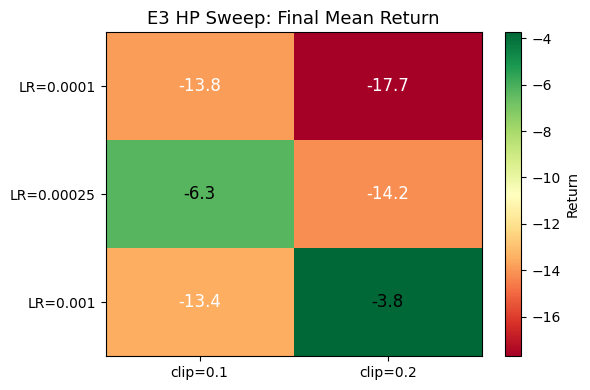

In [14]:
# ======================================================================
# CELL 14: Hyperparameter Sweep Heatmap
# ======================================================================

pivot = (
    sweep_df
    .pivot(index="lr", columns="clip_coef", values="final_mean")
    .sort_index()
    .sort_index(axis=1)
)

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(pivot.values, cmap="RdYlGn", aspect="auto")

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f"clip={c}" for c in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f"LR={lr}" for lr in pivot.index])

pivot_mean = np.nanmean(pivot.values)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        value = pivot.values[i, j]
        ax.text(
            j, i,
            f"{value:.1f}",
            ha="center", va="center",
            fontsize=12,
            color="white" if value < pivot_mean else "black",
        )

ax.set_title("E3 HP Sweep: Final Mean Return", fontsize=13)
plt.colorbar(im, ax=ax, label="Return")
plt.tight_layout()
plt.savefig(project_root / "outputs" / "plots" / "e3_hp_sweep.png", dpi=150, bbox_inches="tight")
print("Saved -> e3_hp_sweep.png")
plt.show()


In [15]:
# ======================================================================
# CELL 15: Load Best Final Model for Attribution and Probing
# ======================================================================

best_seed = max(all_summaries, key=lambda s: all_summaries[s]["best_episode_return"])
ckpt_path = project_root / "outputs" / "checkpoints" / f"E3_final_seed{best_seed}" / "best.pt"

agent = E3Agent(action_dim=action_dim).to(device)
agent.load_state_dict(load_checkpoint_state_dict(ckpt_path, device))
agent.eval()

print(f"Loaded best seed {best_seed} from {ckpt_path}")
print(f"best_return = {all_summaries[best_seed]['best_episode_return']}")


YOLO backbone (yolov8n, layers[:7]) output: C=128, H=6, W=6 -> per-frame dim = 4608
E3Agent: flat_dim=18432 -> 512 -> 512 -> (actor=6, critic=1)
Loaded best seed 0 from E3_experiment_windows_gpu_YOLO\outputs\checkpoints\E3_final_seed0\best.pt
best_return = 20.0


Saved -> e3_gradcam.png


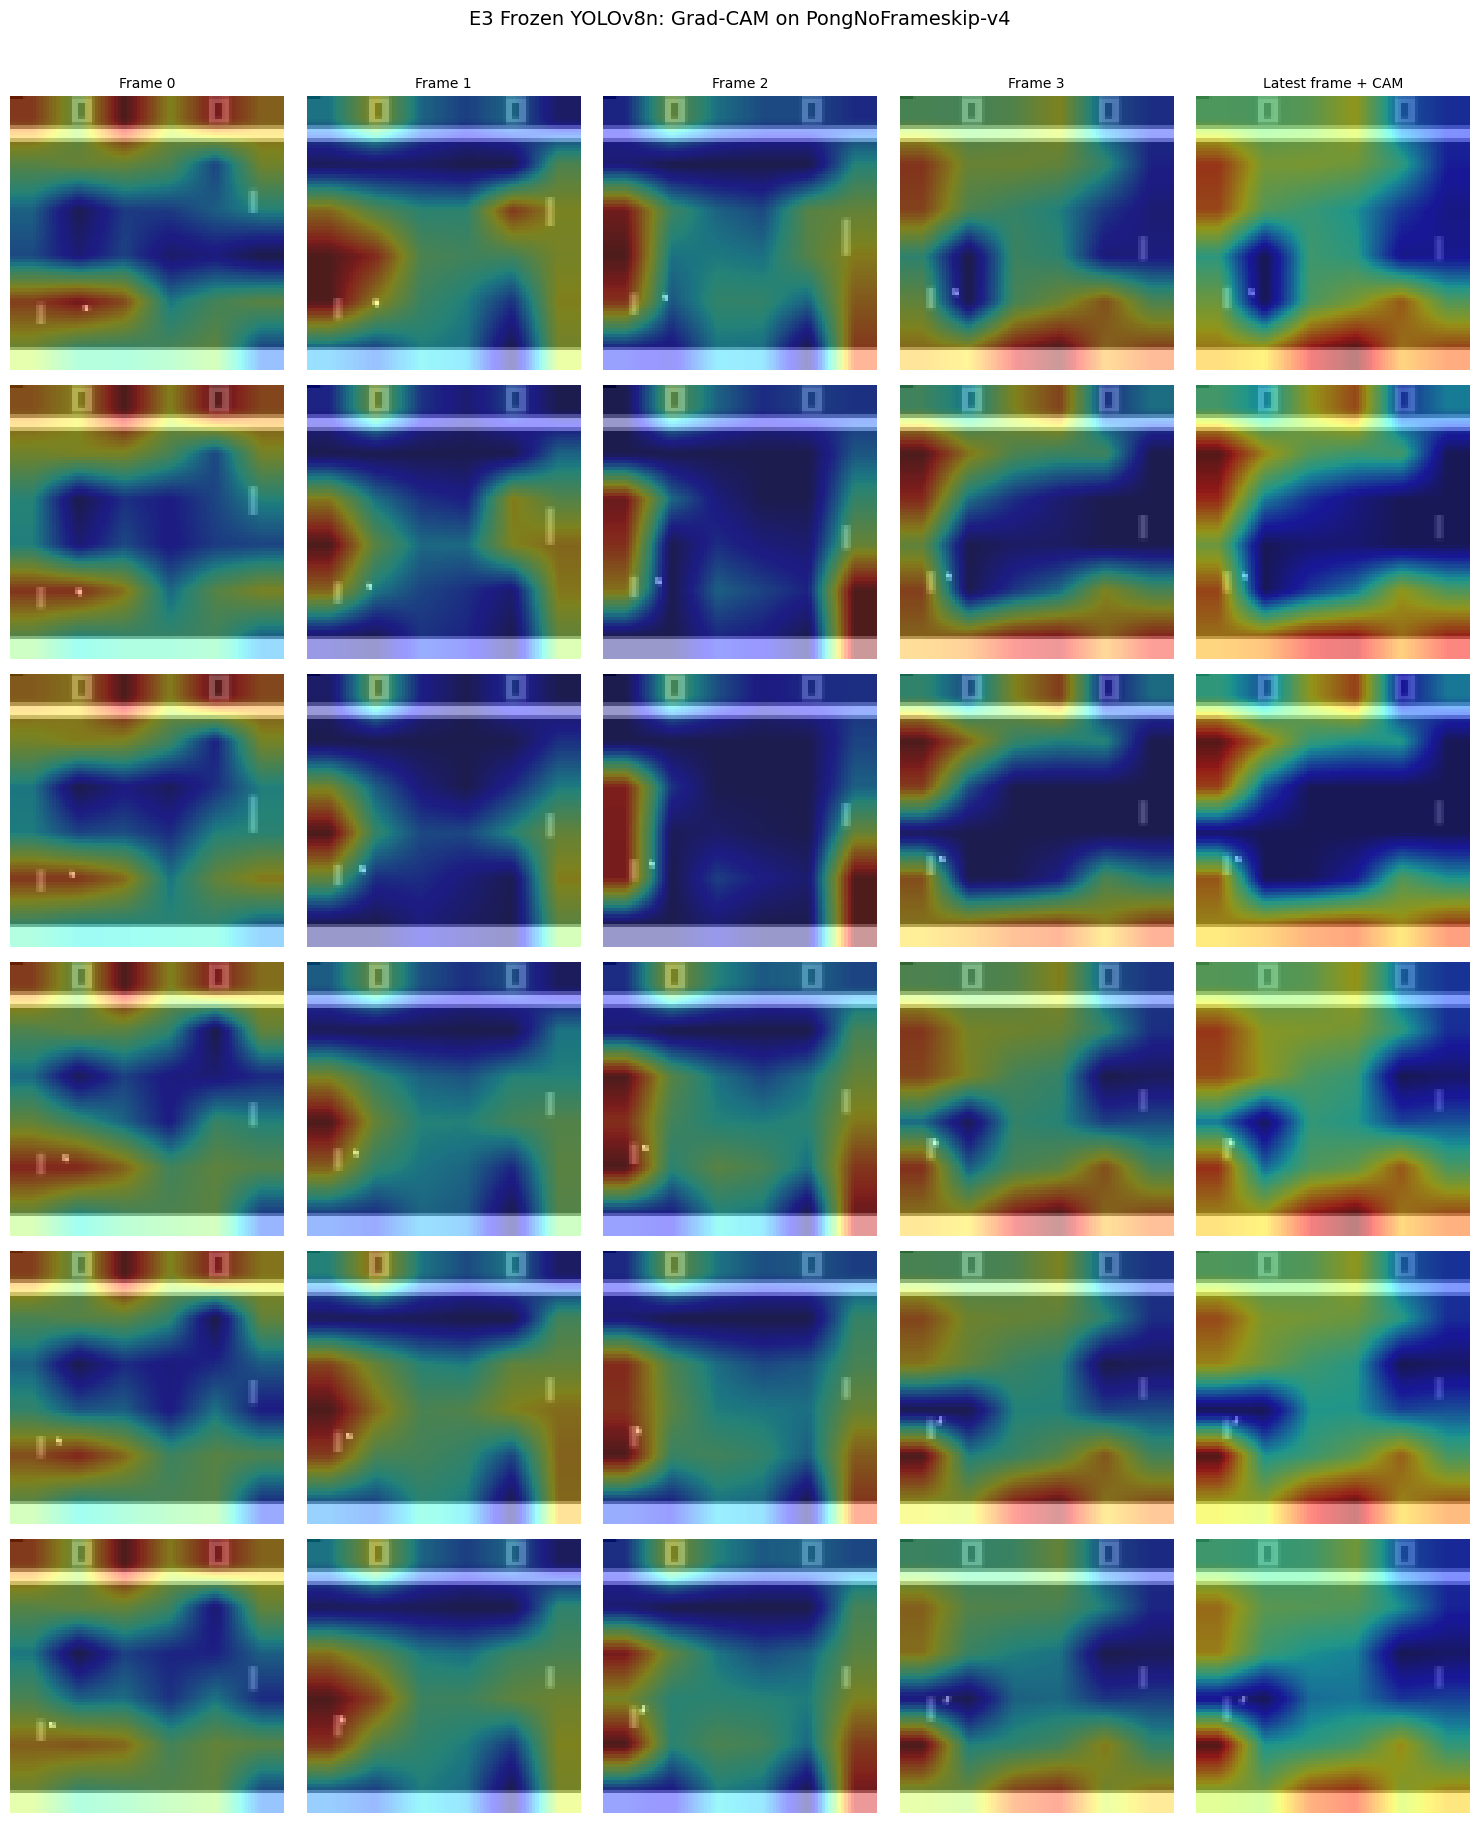

In [16]:
# ======================================================================
# CELL 16: Grad-CAM
# Hooks the output of the last backbone layer (layer 6 / C2f), which is
# structurally analogous to the last ResNet block used in E2's Grad-CAM.
# ======================================================================

class GradCAME3:
    def __init__(self, agent):
        self.agent = agent
        self.gradients = None
        self.activations = None

    def _hook(self, grad):
        self.gradients = grad

    def generate(self, obs_single, target_action=None):
        self.agent.eval()

        x = obs_single.float() / 255.0
        x = x.reshape(NUM_STACK, 1, 84, 84).repeat(1, 3, 1, 1)
        x = (x - self.agent.encoder.mean) / self.agent.encoder.std
        x.requires_grad_(True)

        features = self.agent.encoder.backbone(x)          # (4, C, H, W)
        features.register_hook(self._hook)
        self.activations = features

        z = features.view(1, -1)
        h = self.agent.projection(z)
        h = self.agent.shared(h)
        logits = self.agent.actor(h)

        if target_action is None:
            target_action = logits.argmax(-1).item()

        self.agent.zero_grad()
        logits[0, target_action].backward()

        grads = self.gradients.detach()
        acts  = self.activations.detach()

        weights = grads.mean(dim=[2, 3])                   # (4, C)
        cam = (weights[:, :, None, None] * acts).sum(dim=1)  # (4, H, W)
        cam = F.relu(cam)
        cam = F.interpolate(cam.unsqueeze(1), size=(84, 84),
                            mode="bilinear", align_corners=False).squeeze(1)

        for i in range(NUM_STACK):
            c = cam[i]
            if c.max() > c.min():
                cam[i] = (c - c.min()) / (c.max() - c.min())
            else:
                cam[i] = torch.zeros_like(c)

        return cam.cpu().numpy(), target_action


gradcam = GradCAME3(agent)
viz_env = make_env(0, 0)()
obs, _ = viz_env.reset(seed=0)

for _ in range(80):
    obs, _, terminated, truncated, _ = viz_env.step(viz_env.action_space.sample())
    if terminated or truncated:
        obs, _ = viz_env.reset()

action_meanings = viz_env.unwrapped.get_action_meanings()
NUM_ROWS = 6

fig, axes = plt.subplots(NUM_ROWS, 5, figsize=(15, 3 * NUM_ROWS))

for row in range(NUM_ROWS):
    obs_t = torch.as_tensor(np.asarray(obs), dtype=torch.uint8, device=device).unsqueeze(0)
    cam_maps, act = gradcam.generate(obs_t)

    for col in range(NUM_STACK):
        axes[row, col].imshow(np.asarray(obs)[col], cmap="gray")
        axes[row, col].imshow(cam_maps[col], cmap="jet", alpha=0.4)
        if row == 0:
            axes[row, col].set_title(f"Frame {col}", fontsize=10)
        axes[row, col].axis("off")

    axes[row, 4].imshow(np.asarray(obs)[-1], cmap="gray")
    axes[row, 4].imshow(cam_maps[-1], cmap="jet", alpha=0.5)
    if row == 0:
        axes[row, 4].set_title("Latest frame + CAM", fontsize=10)
    axes[row, 4].axis("off")
    axes[row, 0].set_ylabel(f"{action_meanings[act]}", fontsize=9, rotation=0, labelpad=50)

    with torch.no_grad():
        a_t, _, _, _ = agent.get_action_and_value(obs_t)

    obs, _, terminated, truncated, _ = viz_env.step(a_t.cpu().item())
    if terminated or truncated:
        obs, _ = viz_env.reset()

plt.suptitle(f"E3 Frozen YOLOv8{YOLO_MODEL_SIZE}: Grad-CAM on {ENV_ID}", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(project_root / "outputs" / "plots" / "e3_gradcam.png", dpi=150, bbox_inches="tight")
print("Saved -> e3_gradcam.png")
plt.show()

viz_env.close()


Using run: E3_final_seed0
Checkpoint dir: E3_experiment_windows_gpu_YOLO\outputs\checkpoints\E3_final_seed0
Log path: E3_experiment_windows_gpu_YOLO\outputs\logs\E3_final_seed0\train_log.csv

Available snapshots:
    ckpt_500 | step=500,000 | ckpt_500.pt
   ckpt_1000 | step=1,000,000 | ckpt_1000.pt
   ckpt_1500 | step=1,500,000 | ckpt_1500.pt
   ckpt_2000 | step=2,000,000 | ckpt_2000.pt
       final | step=2,000,000 | final.pt

Selected snapshots:
  target=500,000 -> ckpt_500 (actual=500,000, update=500)
  target=1,000,000 -> ckpt_1000 (actual=1,000,000, update=1000)
  target=2,000,000 -> ckpt_2000 (actual=2,000,000, update=2000)
YOLO backbone (yolov8n, layers[:7]) output: C=128, H=6, W=6 -> per-frame dim = 4608
E3Agent: flat_dim=18432 -> 512 -> 512 -> (actor=6, critic=1)
YOLO backbone (yolov8n, layers[:7]) output: C=128, H=6, W=6 -> per-frame dim = 4608
E3Agent: flat_dim=18432 -> 512 -> 512 -> (actor=6, critic=1)
YOLO backbone (yolov8n, layers[:7]) output: C=128, H=6, W=6 -> per-frame

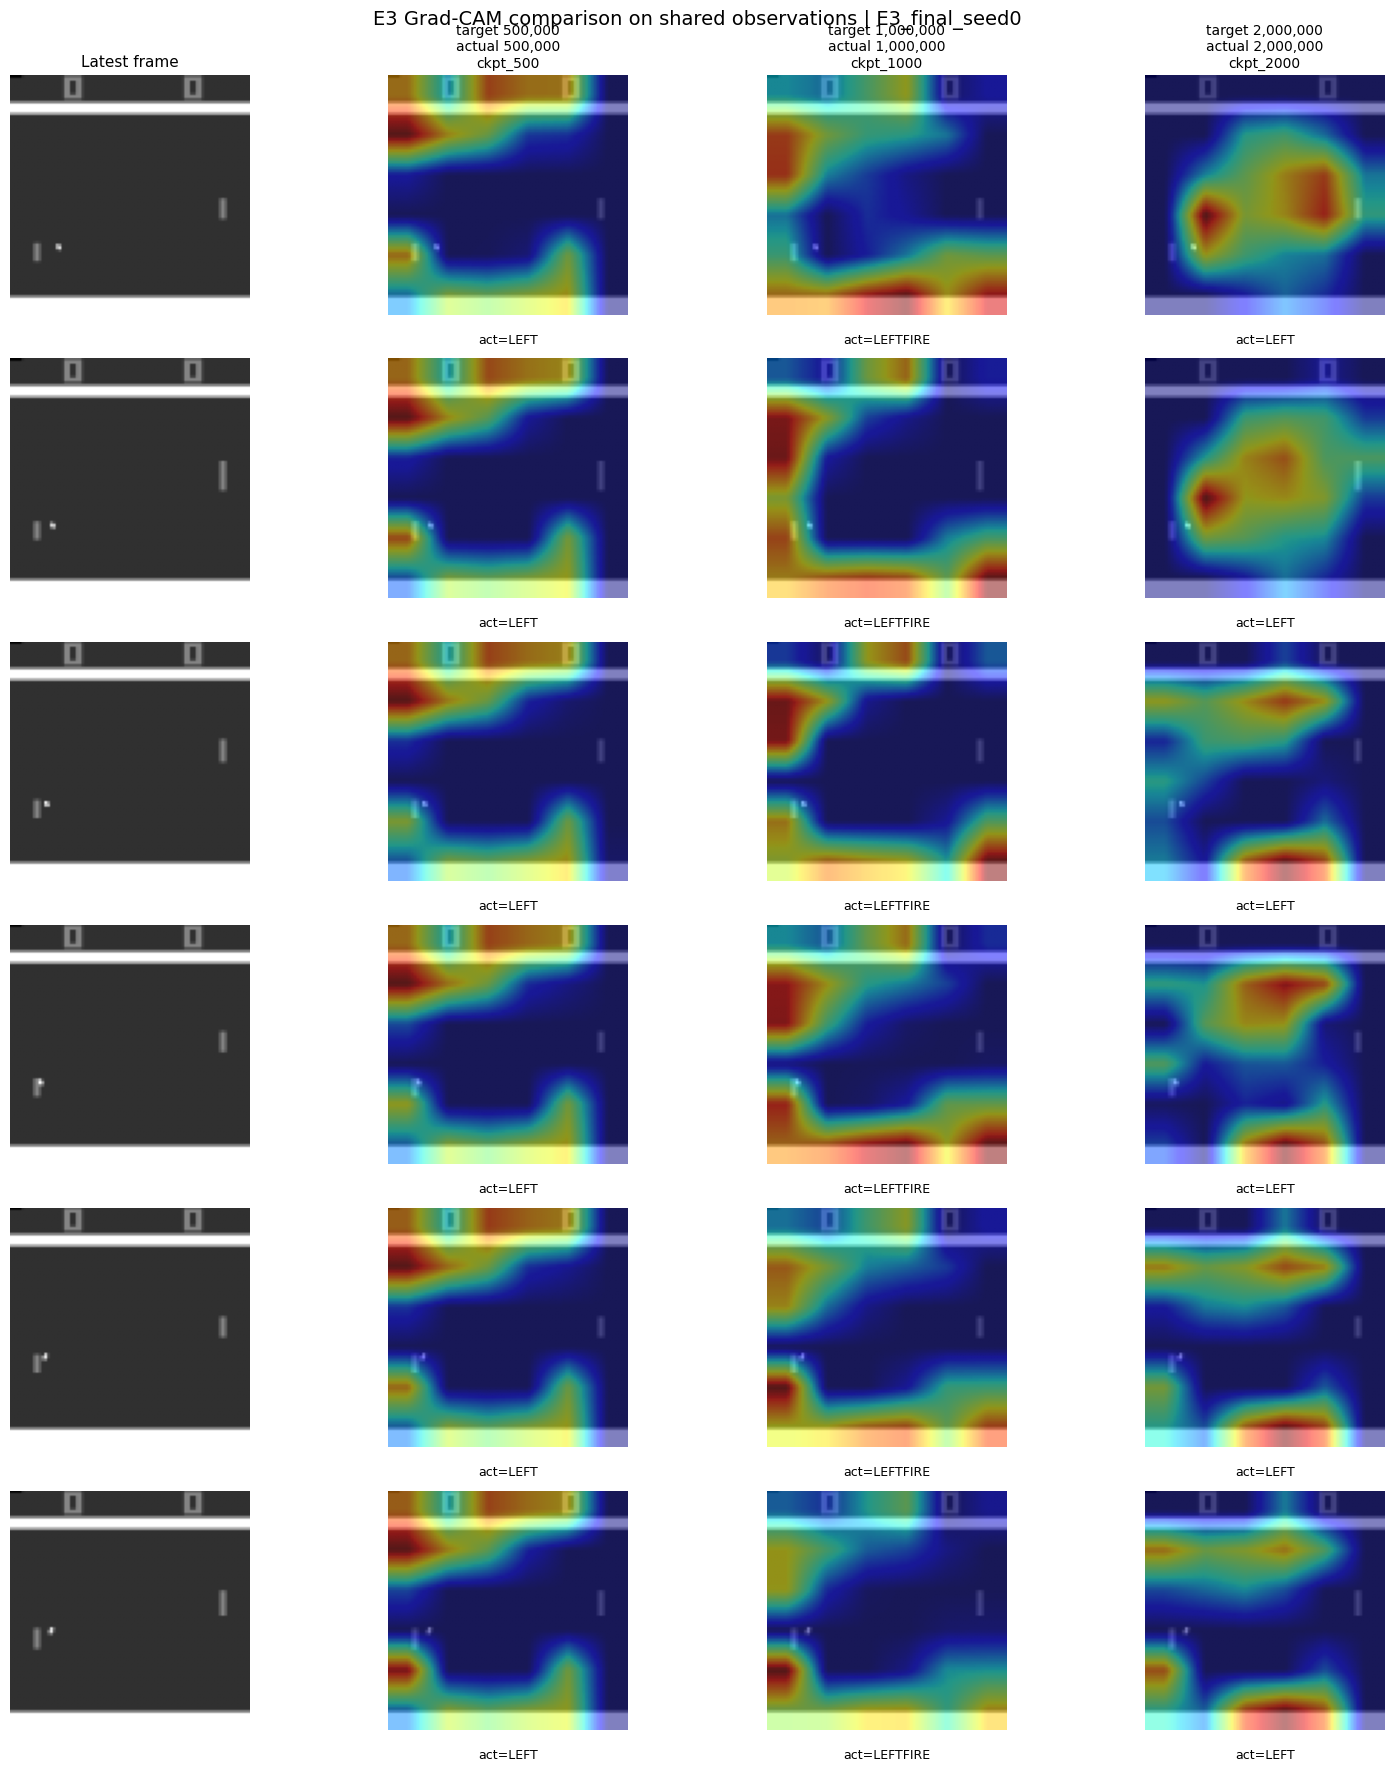


Saved -> E3_experiment_windows_gpu_YOLO\outputs\plots\e3_gradcam_compare_E3_final_seed0.png


In [17]:
# ======================================================================
# CELL 17: Compare Grad-CAM across training stages (nearest checkpoints)
# ======================================================================

import re

COMPARE_TARGET_STEPS = [500_000, 1_000_000, 2_000_000]
NUM_ROWS = 6
BURN_IN_RANDOM = 80
TRAJ_SEED = 0

run_seed = best_seed if "best_seed" in globals() else 0

run_name = f"E3_final_seed{run_seed}"
ckpt_dir_cmp = project_root / "outputs" / "checkpoints" / run_name
log_path_cmp = project_root / "outputs" / "logs"        / run_name / "train_log.csv"

print(f"Using run: {run_name}")
print(f"Checkpoint dir: {ckpt_dir_cmp}")
print(f"Log path: {log_path_cmp}")

assert ckpt_dir_cmp.exists(), f"Checkpoint directory not found: {ckpt_dir_cmp}"
assert log_path_cmp.exists(), f"Train log not found: {log_path_cmp}"


class GradCAME3Compare:
    def __init__(self, agent):
        self.agent = agent
        self.gradients = None
        self.activations = None

    def _hook(self, grad):
        self.gradients = grad

    def generate(self, obs_single, target_action=None):
        self.agent.eval()

        x = obs_single.float() / 255.0
        x = x.reshape(4, 1, 84, 84).repeat(1, 3, 1, 1)
        x = (x - self.agent.encoder.mean) / self.agent.encoder.std
        x.requires_grad_(True)

        features = self.agent.encoder.backbone(x)
        features.register_hook(self._hook)
        self.activations = features

        z = features.view(1, -1)
        h = self.agent.projection(z)
        h = self.agent.shared(h)
        logits = self.agent.actor(h)

        if target_action is None:
            target_action = logits.argmax(-1).item()

        self.agent.zero_grad()
        logits[0, target_action].backward()

        grads = self.gradients.detach()
        acts  = self.activations.detach()

        weights = grads.mean(dim=[2, 3])
        cam = (weights[:, :, None, None] * acts).sum(dim=1)
        cam = F.relu(cam)
        cam = F.interpolate(cam.unsqueeze(1), size=(84, 84),
                            mode="bilinear", align_corners=False).squeeze(1)

        for i in range(4):
            c = cam[i]
            if c.max() > c.min():
                cam[i] = (c - c.min()) / (c.max() - c.min())
            else:
                cam[i] = torch.zeros_like(c)

        return cam.cpu().numpy(), target_action


def load_state_dict_safely(path, device):
    obj = torch.load(path, map_location=device)
    if isinstance(obj, dict):
        if "state_dict" in obj:
            return obj["state_dict"]
        return obj
    raise ValueError(f"Unsupported checkpoint format: {path}")


log_df_cmp = pd.read_csv(log_path_cmp)
assert "update" in log_df_cmp.columns and "global_step" in log_df_cmp.columns

available = []
for p in ckpt_dir_cmp.glob("ckpt_*.pt"):
    m = re.match(r"ckpt_(\d+)\.pt", p.name)
    if not m:
        continue
    upd = int(m.group(1))
    hit = log_df_cmp.loc[log_df_cmp["update"] == upd]
    if len(hit) == 0:
        continue
    step = int(hit.iloc[0]["global_step"])
    available.append({"label": f"ckpt_{upd}", "path": p, "update": upd,
                      "global_step": step, "kind": "periodic"})

final_pt = ckpt_dir_cmp / "final.pt"
if final_pt.exists():
    last_row = log_df_cmp.iloc[-1]
    available.append({"label": "final", "path": final_pt,
                      "update": int(last_row["update"]),
                      "global_step": int(last_row["global_step"]),
                      "kind": "final"})

available = sorted(available, key=lambda x: x["global_step"])
assert len(available) > 0, f"No periodic/final checkpoints found in {ckpt_dir_cmp}"

print("\nAvailable snapshots:")
for item in available:
    print(f"  {item['label']:>10s} | step={item['global_step']:,} | {item['path'].name}")

selected = []
for target in COMPARE_TARGET_STEPS:
    best_item = min(available, key=lambda x: abs(x["global_step"] - target))
    selected.append({
        "target_step": target,
        "actual_step": best_item["global_step"],
        "update":      best_item["update"],
        "label":       best_item["label"],
        "path":        best_item["path"],
    })

print("\nSelected snapshots:")
for s in selected:
    print(f"  target={s['target_step']:,} -> {s['label']} "
          f"(actual={s['actual_step']:,}, update={s['update']})")

# Collect shared observations (same across all checkpoints)
viz_env = make_env(TRAJ_SEED, 0)()
obs_cmp, _ = viz_env.reset(seed=TRAJ_SEED)
rng = np.random.default_rng(TRAJ_SEED)

for _ in range(BURN_IN_RANDOM):
    a = int(rng.integers(viz_env.action_space.n))
    obs_cmp, _, terminated, truncated, _ = viz_env.step(a)
    if terminated or truncated:
        obs_cmp, _ = viz_env.reset(seed=TRAJ_SEED)

shared_obs = []
for _ in range(NUM_ROWS):
    shared_obs.append(np.asarray(obs_cmp).copy())
    a = int(rng.integers(viz_env.action_space.n))
    obs_cmp, _, terminated, truncated, _ = viz_env.step(a)
    if terminated or truncated:
        obs_cmp, _ = viz_env.reset(seed=TRAJ_SEED)

action_meanings_cmp = viz_env.unwrapped.get_action_meanings()

results = []
for s in selected:
    agent_cmp = E3Agent(action_dim=action_dim).to(device)
    agent_cmp.load_state_dict(load_state_dict_safely(s["path"], device))
    agent_cmp.eval()

    gradcam_cmp = GradCAME3Compare(agent_cmp)

    cam_list, act_list = [], []
    for obs_np in shared_obs:
        obs_t = torch.as_tensor(obs_np, dtype=torch.uint8, device=device).unsqueeze(0)
        cam_maps, act = gradcam_cmp.generate(obs_t)
        cam_list.append(cam_maps)
        act_list.append(act)

    results.append({"meta": s, "cams": cam_list, "actions": act_list})

ncols = 1 + len(results)
fig, axes = plt.subplots(NUM_ROWS, ncols, figsize=(4 * ncols, 3 * NUM_ROWS))
if NUM_ROWS == 1:
    axes = np.expand_dims(axes, axis=0)

axes[0, 0].set_title("Latest frame", fontsize=11)
for j, r in enumerate(results, start=1):
    meta = r["meta"]
    axes[0, j].set_title(f"target {meta['target_step']:,}\nactual {meta['actual_step']:,}\n{meta['label']}",
                         fontsize=10)

for i in range(NUM_ROWS):
    obs_np = shared_obs[i]
    latest_frame = obs_np[-1]

    axes[i, 0].imshow(latest_frame, cmap="gray")
    axes[i, 0].axis("off")
    axes[i, 0].set_ylabel(f"Obs {i}", fontsize=10)

    for j, r in enumerate(results, start=1):
        cam_latest = r["cams"][i][-1]
        act = r["actions"][i]
        axes[i, j].imshow(latest_frame, cmap="gray")
        axes[i, j].imshow(cam_latest, cmap="jet", alpha=0.5)
        axes[i, j].axis("off")
        axes[i, j].text(0.5, -0.08, f"act={action_meanings_cmp[act]}",
                        transform=axes[i, j].transAxes,
                        ha="center", va="top", fontsize=9)

plt.suptitle(f"E3 Grad-CAM comparison on shared observations | {run_name}", fontsize=14)
plt.tight_layout()

save_path = project_root / "outputs" / "plots" / f"e3_gradcam_compare_{run_name}.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()

viz_env.close()
print(f"\nSaved -> {save_path}")


Saved -> e3_integrated_gradients.png


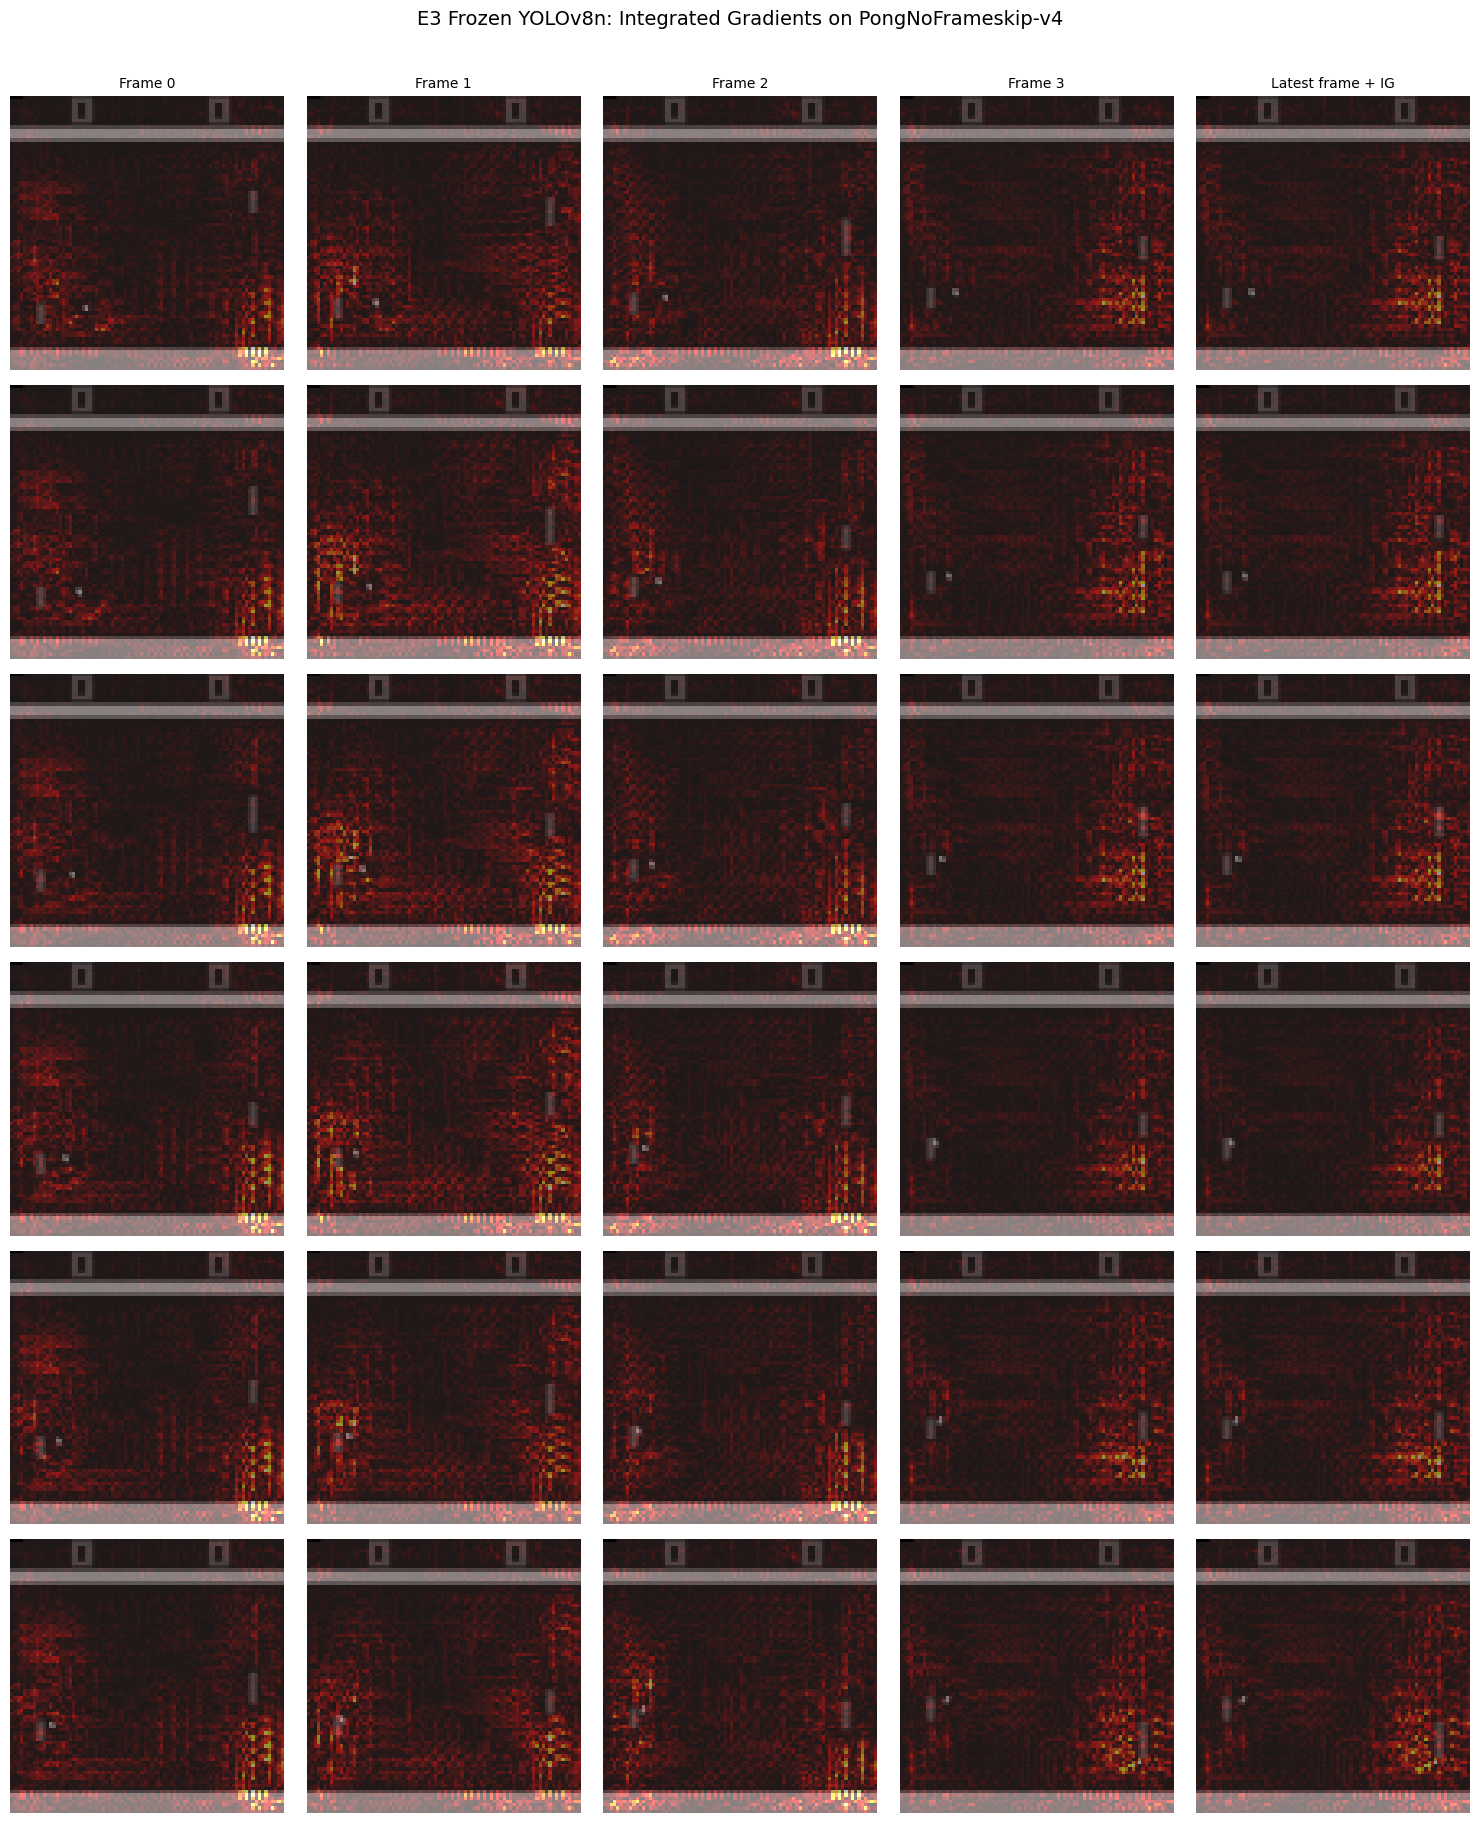

In [18]:
# ======================================================================
# CELL 18: Integrated Gradients
# ======================================================================

class IntegratedGradientsE3:
    def __init__(self, agent, n_steps=50):
        self.agent = agent
        self.n_steps = n_steps

    def generate(self, obs_single, target_action=None):
        self.agent.eval()

        baseline = torch.zeros_like(obs_single, dtype=torch.float32)
        inp = obs_single.float()

        if target_action is None:
            with torch.no_grad():
                h = self.agent.forward_features(obs_single)
                target_action = self.agent.actor(h).argmax(-1).item()

        all_grads = []
        for k in range(self.n_steps + 1):
            alpha = k / self.n_steps
            scaled = (baseline + alpha * (inp - baseline)).clone().requires_grad_(True)

            x = scaled / 255.0
            x = x.reshape(NUM_STACK, 1, 84, 84).repeat(1, 3, 1, 1)
            x = (x - self.agent.encoder.mean) / self.agent.encoder.std

            feat = self.agent.encoder.backbone(x)
            z = feat.view(1, -1)
            h = self.agent.projection(z)
            h = self.agent.shared(h)
            logits = self.agent.actor(h)

            self.agent.zero_grad()
            logits[0, target_action].backward()
            all_grads.append(scaled.grad.detach().clone())

        avg_grad = torch.stack(all_grads).mean(0)
        attr = ((inp - baseline) * avg_grad).squeeze(0).abs()

        for i in range(NUM_STACK):
            a = attr[i]
            if a.max() > a.min():
                attr[i] = (a - a.min()) / (a.max() - a.min())
            else:
                attr[i] = torch.zeros_like(a)

        return attr.cpu().numpy(), target_action


ig = IntegratedGradientsE3(agent, n_steps=50)
viz_env = make_env(0, 0)()
obs, _ = viz_env.reset(seed=0)

for _ in range(80):
    obs, _, terminated, truncated, _ = viz_env.step(viz_env.action_space.sample())
    if terminated or truncated:
        obs, _ = viz_env.reset()

fig, axes = plt.subplots(NUM_ROWS, 5, figsize=(15, 3 * NUM_ROWS))

for row in range(NUM_ROWS):
    obs_t = torch.as_tensor(np.asarray(obs), dtype=torch.uint8, device=device).unsqueeze(0)
    attr_maps, act = ig.generate(obs_t)

    for col in range(NUM_STACK):
        axes[row, col].imshow(np.asarray(obs)[col], cmap="gray")
        axes[row, col].imshow(attr_maps[col], cmap="hot", alpha=0.5)
        if row == 0:
            axes[row, col].set_title(f"Frame {col}", fontsize=10)
        axes[row, col].axis("off")

    axes[row, 4].imshow(np.asarray(obs)[-1], cmap="gray")
    axes[row, 4].imshow(attr_maps[-1], cmap="hot", alpha=0.5)
    if row == 0:
        axes[row, 4].set_title("Latest frame + IG", fontsize=10)
    axes[row, 4].axis("off")
    axes[row, 0].set_ylabel(f"{action_meanings[act]}", fontsize=9, rotation=0, labelpad=50)

    with torch.no_grad():
        a_t, _, _, _ = agent.get_action_and_value(obs_t)

    obs, _, terminated, truncated, _ = viz_env.step(a_t.cpu().item())
    if terminated or truncated:
        obs, _ = viz_env.reset()

plt.suptitle(f"E3 Frozen YOLOv8{YOLO_MODEL_SIZE}: Integrated Gradients on {ENV_ID}", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(project_root / "outputs" / "plots" / "e3_integrated_gradients.png", dpi=150, bbox_inches="tight")
print("Saved -> e3_integrated_gradients.png")
plt.show()

viz_env.close()


  1000/5000
  2000/5000
  3000/5000
  4000/5000
  5000/5000
Dataset: (5000, 4, 84, 84)
Random baseline: 22.49 px

Extracting features...
Spatial: (5000, 18432)
Policy:  (5000, 512)

Linear Probe: Spatial vs Policy Features
  [Spatial] Epoch 25: 25.23 px
  [Spatial] Epoch 50: 20.44 px
  [Spatial] Epoch 75: 19.09 px
  [Spatial] Epoch 100: 17.74 px
  [Spatial] Final: 17.74 px
  [Policy] Epoch 25: 70.84 px
  [Policy] Epoch 50: 69.25 px
  [Policy] Epoch 75: 67.68 px
  [Policy] Epoch 100: 66.14 px
  [Policy] Final: 66.14 px

Feature                    Dims      Error    vs Random
--------------------------------------------------------
Random baseline               -      22.49            -
Spatial (backbone)        18432      17.74        21.1%
Policy (head)                   512      66.14      -194.0%
Saved -> e3_linear_probe.png


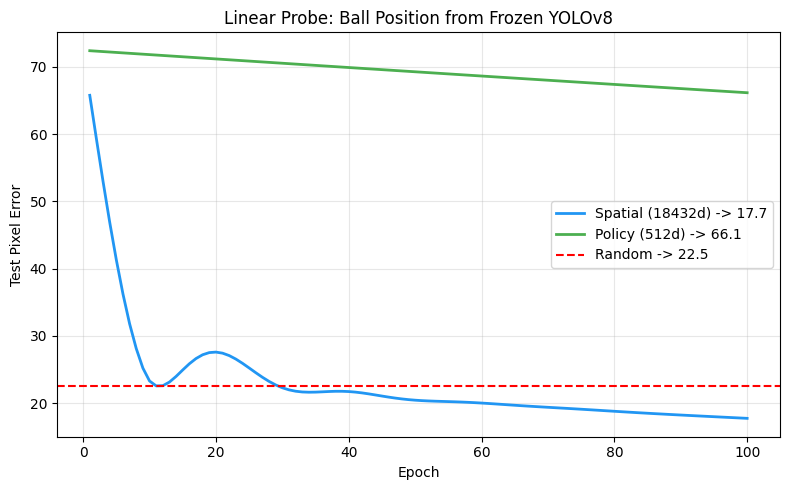

Saved -> e3_linear_probe_bar.png


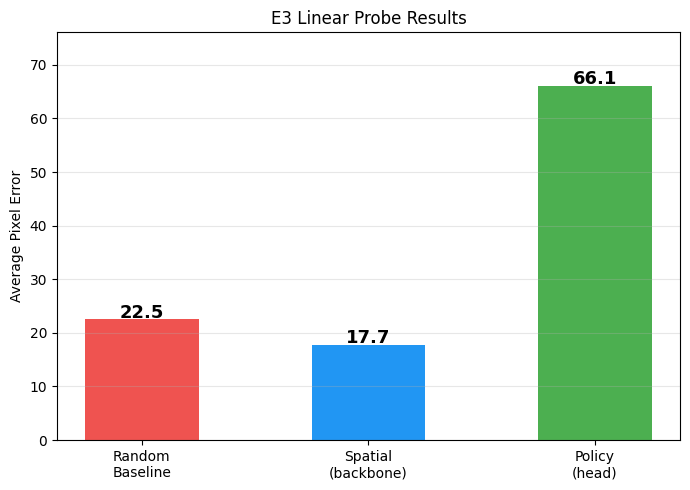

Saved probe features for later CKA or report usage.


In [19]:
# ======================================================================
# CELL 19: Linear Probe — Ball Position Prediction
# Compare backbone spatial features vs policy features.
# For YOLOv8n layers[:7] at 84x84: spatial dim = 128*6*6 = 4,608
# (× 4 frames -> 18,432 flattened, same as E2).
# ======================================================================

from scipy import ndimage
from sklearn.model_selection import train_test_split

def find_ball_position(frame):
    binary = (frame > 200).astype(np.uint8)
    labeled, n = ndimage.label(binary)
    if n == 0:
        return None

    best_pos, best_size = None, 999
    for lid in range(1, n + 1):
        ys, xs = np.where(labeled == lid)
        size = len(ys)
        if 1 <= size <= 10 and size < best_size:
            best_size = size
            best_pos = (float(ys.mean()), float(xs.mean()))
    return best_pos


print("Collecting probing dataset...")
probe_env = make_env(0, 0)()
observations, positions = [], []

obs_p, _ = probe_env.reset(seed=0)
collected = 0

while collected < 5000:
    obs_p, _, terminated, truncated, _ = probe_env.step(probe_env.action_space.sample())
    if terminated or truncated:
        obs_p, _ = probe_env.reset()
        continue

    pos = find_ball_position(np.asarray(obs_p)[-1])
    if pos is not None:
        observations.append(np.asarray(obs_p))
        positions.append(pos)
        collected += 1
        if collected % 1000 == 0:
            print(f"  {collected}/5000")

probe_env.close()

obs_data = np.asarray(observations, dtype=np.uint8)
ball_data = np.asarray(positions, dtype=np.float32)

print("Dataset:", obs_data.shape)

mean_pos = ball_data.mean(axis=0)
random_baseline = np.sqrt(((ball_data - mean_pos) ** 2).sum(axis=1)).mean()
print(f"Random baseline: {random_baseline:.2f} px")

print("\nExtracting features...")
agent.eval()

feats_spatial = []
with torch.no_grad():
    for i in range(0, len(obs_data), 64):
        batch = torch.as_tensor(obs_data[i:i+64], dtype=torch.uint8, device=device)
        B = batch.shape[0]
        x = batch.float() / 255.0
        x = x.reshape(B * NUM_STACK, 1, 84, 84).repeat(1, 3, 1, 1)
        x = (x - agent.encoder.mean) / agent.encoder.std
        z = agent.encoder.backbone(x)
        feats_spatial.append(z.view(B, -1).cpu())

feats_spatial = torch.cat(feats_spatial).numpy()

feats_policy = []
with torch.no_grad():
    for i in range(0, len(obs_data), 128):
        batch = torch.as_tensor(obs_data[i:i+128], dtype=torch.uint8, device=device)
        feats_policy.append(agent.forward_features(batch).cpu())

feats_policy = torch.cat(feats_policy).numpy()

print("Spatial:", feats_spatial.shape)
print("Policy: ", feats_policy.shape)


def train_probe(features, targets, name, epochs=100, lr=1e-3):
    X_tr, X_te, y_tr, y_te = train_test_split(features, targets, test_size=0.2, random_state=42)

    X_tr = torch.as_tensor(X_tr, dtype=torch.float32)
    X_te = torch.as_tensor(X_te, dtype=torch.float32)
    y_tr = torch.as_tensor(y_tr, dtype=torch.float32)
    y_te = torch.as_tensor(y_te, dtype=torch.float32)

    probe = nn.Linear(features.shape[1], 2)
    opt = torch.optim.Adam(probe.parameters(), lr=lr)

    test_errs = []
    for epoch in range(epochs):
        probe.train()
        loss = F.mse_loss(probe(X_tr), y_tr)
        opt.zero_grad()
        loss.backward()
        opt.step()

        probe.eval()
        with torch.no_grad():
            err = torch.sqrt(((probe(X_te) - y_te) ** 2).sum(1)).mean().item()

        test_errs.append(err)
        if (epoch + 1) % 25 == 0:
            print(f"  [{name}] Epoch {epoch + 1}: {err:.2f} px")

    print(f"  [{name}] Final: {test_errs[-1]:.2f} px")
    return test_errs[-1], test_errs


print(f"\n{'='*68}\nLinear Probe: Spatial vs Policy Features\n{'='*68}")
err_sp, curve_sp = train_probe(feats_spatial, ball_data, "Spatial")
err_po, curve_po = train_probe(feats_policy,  ball_data, "Policy")

print(f"\n{'='*68}")
print(f"{'Feature':<22} {'Dims':>8} {'Error':>10} {'vs Random':>12}")
print(f"{'-'*56}")
print(f"{'Random baseline':<22} {'-':>8} {random_baseline:>10.2f} {'-':>12}")
print(f"{'Spatial (backbone)':<22} {feats_spatial.shape[1]:>8} {err_sp:>10.2f} {(1 - err_sp / random_baseline) * 100:>11.1f}%")
print(f"{'Policy (head)':<22}     {feats_policy.shape[1]:>8} {err_po:>10.2f} {(1 - err_po / random_baseline) * 100:>11.1f}%")
print(f"{'='*68}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(curve_sp) + 1), curve_sp, lw=2, color="#2196F3",
        label=f"Spatial ({feats_spatial.shape[1]}d) -> {err_sp:.1f}")
ax.plot(range(1, len(curve_po) + 1), curve_po, lw=2, color="#4CAF50",
        label=f"Policy ({feats_policy.shape[1]}d) -> {err_po:.1f}")
ax.axhline(random_baseline, color="red", linestyle="--", lw=1.5,
           label=f"Random -> {random_baseline:.1f}")
ax.set_xlabel("Epoch")
ax.set_ylabel("Test Pixel Error")
ax.set_title("Linear Probe: Ball Position from Frozen YOLOv8")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(project_root / "outputs" / "plots" / "e3_linear_probe.png", dpi=150, bbox_inches="tight")
print("Saved -> e3_linear_probe.png")
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
names  = ["Random\nBaseline", "Spatial\n(backbone)", "Policy\n(head)"]
vals   = [random_baseline, err_sp, err_po]
colors = ["#EF5350", "#2196F3", "#4CAF50"]
bars   = ax.bar(names, vals, color=colors, width=0.5)

for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
            f"{v:.1f}", ha="center", fontsize=13, fontweight="bold")

ax.set_ylabel("Average Pixel Error")
ax.set_title("E3 Linear Probe Results")
ax.set_ylim(0, max(vals) * 1.15)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(project_root / "outputs" / "plots" / "e3_linear_probe_bar.png", dpi=150, bbox_inches="tight")
print("Saved -> e3_linear_probe_bar.png")
plt.show()

probe_results = {
    "random_baseline": float(random_baseline),
    "spatial": {"dims": int(feats_spatial.shape[1]), "error": float(err_sp)},
    "policy":  {"dims": int(feats_policy.shape[1]),  "error": float(err_po)},
}

with open(project_root / "outputs" / "tables" / "linear_probe_results.json", "w") as f:
    json.dump(probe_results, f, indent=2)

np.save(project_root / "outputs" / "tables" / "shared_obs_data.npy",  obs_data)
np.save(project_root / "outputs" / "tables" / "e3_features_spatial.npy", feats_spatial)
np.save(project_root / "outputs" / "tables" / "e3_features_policy.npy",  feats_policy)

print("Saved probe features for later CKA or report usage.")


In [20]:
# ======================================================================
# CELL 20: CKA Similarity Helper (optional, compare E3 vs E1/E2 features)
# ======================================================================

def linear_CKA(X, Y):
    X = X - X.mean(axis=0)
    Y = Y - Y.mean(axis=0)

    hsic_xy = np.linalg.norm(X.T @ Y, ord="fro") ** 2
    hsic_xx = np.linalg.norm(X.T @ X, ord="fro") ** 2
    hsic_yy = np.linalg.norm(Y.T @ Y, ord="fro") ** 2

    return hsic_xy / (np.sqrt(hsic_xx * hsic_yy) + 1e-10)


print("CKA helper is ready. Load E1 / E2 features separately (saved as .npy) to compare.")
# Example:
# e1 = np.load("path/to/E1_features_policy.npy")
# e2 = np.load("path/to/E2_features_policy.npy")
# e3 = np.load(project_root / "outputs" / "tables" / "e3_features_policy.npy")
# print("CKA(E1, E3):", linear_CKA(e1, e3))
# print("CKA(E2, E3):", linear_CKA(e2, e3))


CKA helper is ready. Load E1 / E2 features separately (saved as .npy) to compare.


In [21]:
# ======================================================================
# CELL 21: Deliverables Check
# ======================================================================

print("=" * 68)
print("E3 Experiment — Deliverables Check")
print("=" * 68)

files = [
    ("HP Sweep Table",        "outputs/tables/hp_sweep.csv"),
    ("5-Seed Summary",        "outputs/tables/final_summaries.json"),
    ("Linear Probe Results",  "outputs/tables/linear_probe_results.json"),
    ("Baselines",             "outputs/tables/baselines.json"),
    ("Return Curve",          "outputs/plots/e3_return_curve.png"),
    ("HP Sweep Heatmap",      "outputs/plots/e3_hp_sweep.png"),
    ("Grad-CAM",              "outputs/plots/e3_gradcam.png"),
    ("Integrated Gradients",  "outputs/plots/e3_integrated_gradients.png"),
    ("Linear Probe Curves",   "outputs/plots/e3_linear_probe.png"),
    ("Linear Probe Bar",      "outputs/plots/e3_linear_probe_bar.png"),
    ("Shared Obs (CKA)",      "outputs/tables/shared_obs_data.npy"),
    ("E3 Features Spatial",   "outputs/tables/e3_features_spatial.npy"),
    ("E3 Features Policy",    "outputs/tables/e3_features_policy.npy"),
]

for name, rel_path in files:
    ok = "OK" if (project_root / rel_path).exists() else "MISSING"
    print(f"{ok:<8} {name:<24} {rel_path}")

print()
for seed in FINAL_SEEDS:
    log_ok  = (project_root / "outputs" / "logs"        / f"E3_final_seed{seed}" / "train_log.csv").exists()
    ckpt_ok = (project_root / "outputs" / "checkpoints" / f"E3_final_seed{seed}" / "best.pt").exists()
    print(f"Seed {seed}: log={'OK' if log_ok else 'MISSING'} | ckpt={'OK' if ckpt_ok else 'MISSING'}")

print(f"\nProject root: {project_root.resolve()}")


E3 Experiment — Deliverables Check
OK       HP Sweep Table           outputs/tables/hp_sweep.csv
OK       5-Seed Summary           outputs/tables/final_summaries.json
OK       Linear Probe Results     outputs/tables/linear_probe_results.json
MISSING  Baselines                outputs/tables/baselines.json
OK       Return Curve             outputs/plots/e3_return_curve.png
OK       HP Sweep Heatmap         outputs/plots/e3_hp_sweep.png
OK       Grad-CAM                 outputs/plots/e3_gradcam.png
OK       Integrated Gradients     outputs/plots/e3_integrated_gradients.png
OK       Linear Probe Curves      outputs/plots/e3_linear_probe.png
OK       Linear Probe Bar         outputs/plots/e3_linear_probe_bar.png
OK       Shared Obs (CKA)         outputs/tables/shared_obs_data.npy
OK       E3 Features Spatial      outputs/tables/e3_features_spatial.npy
OK       E3 Features Policy       outputs/tables/e3_features_policy.npy

Seed 0: log=OK | ckpt=OK
Seed 1: log=OK | ckpt=OK
Seed 2: log=OK | c

In [22]:
# ======================================================================
# CELL 22: Optional Controls — Random Policy and Simple Heuristic
# ======================================================================

def evaluate_policy(policy_fn, n_episodes=100, seed=0):
    env = make_env(seed, 0)()
    returns = []

    obs, _ = env.reset(seed=seed)
    ep_ret = 0.0

    while len(returns) < n_episodes:
        action = policy_fn(obs, env)
        obs, reward, terminated, truncated, _ = env.step(action)
        ep_ret += reward

        if terminated or truncated:
            returns.append(ep_ret)
            ep_ret = 0.0
            obs, _ = env.reset()

    env.close()
    return returns


def random_policy(obs, env):
    return env.action_space.sample()


def heuristic_policy(obs, env):
    frame = np.asarray(obs)[-1]

    binary = (frame > 200).astype(np.uint8)
    labeled, n = ndimage.label(binary)

    ball_y = None
    best_size = 999
    for lid in range(1, n + 1):
        ys, xs = np.where(labeled == lid)
        size = len(ys)
        if 1 <= size <= 10 and size < best_size:
            best_size = size
            ball_y = float(ys.mean())

    paddle_y = None
    for lid in range(1, n + 1):
        ys, xs = np.where(labeled == lid)
        if len(ys) > 10 and xs.mean() > 60:
            paddle_y = float(ys.mean())

    if ball_y is None or paddle_y is None:
        return 0

    meanings = env.unwrapped.get_action_meanings()
    move_up   = meanings.index("RIGHT") if "RIGHT" in meanings else 2
    move_down = meanings.index("LEFT")  if "LEFT"  in meanings else 3

    if ball_y < paddle_y - 2:
        return move_up
    if ball_y > paddle_y + 2:
        return move_down
    return 0


print("Evaluating Random Policy (100 episodes)...")
random_returns = evaluate_policy(random_policy, n_episodes=100, seed=0)
print(f"Random:    {np.mean(random_returns):.2f} ± {np.std(random_returns) / np.sqrt(len(random_returns)):.2f} (SE)")

print("\nEvaluating Heuristic Policy (100 episodes)...")
heuristic_returns = evaluate_policy(heuristic_policy, n_episodes=100, seed=0)
print(f"Heuristic: {np.mean(heuristic_returns):.2f} ± {np.std(heuristic_returns) / np.sqrt(len(heuristic_returns)):.2f} (SE)")

e3_means = [s["final_recent_return_mean"] for s in all_summaries.values() if s["final_recent_return_mean"] is not None]

print(f"\n{'='*68}")
print("Controls Summary")
print(f"{'='*68}")
print(f"{'Policy':<22} {'Mean Return':>14} {'± SE':>10}")
print(f"{'-'*50}")
print(f"{'Random':<22} {np.mean(random_returns):>14.2f} {np.std(random_returns) / np.sqrt(len(random_returns)):>10.2f}")
print(f"{'Heuristic':<22} {np.mean(heuristic_returns):>14.2f} {np.std(heuristic_returns) / np.sqrt(len(heuristic_returns)):>10.2f}")
print(f"{'E3 Frozen YOLOv8':<22} {np.mean(e3_means):>14.2f} {np.std(e3_means) / np.sqrt(len(e3_means)):>10.2f}")
print(f"{'='*68}")

baseline_results = {
    "random": {
        "mean": float(np.mean(random_returns)),
        "se":   float(np.std(random_returns) / np.sqrt(len(random_returns))),
    },
    "heuristic": {
        "mean": float(np.mean(heuristic_returns)),
        "se":   float(np.std(heuristic_returns) / np.sqrt(len(heuristic_returns))),
    },
    "e3": {
        "mean": float(np.mean(e3_means)),
        "se":   float(np.std(e3_means) / np.sqrt(len(e3_means))),
    },
}

with open(project_root / "outputs" / "tables" / "baselines.json", "w") as f:
    json.dump(baseline_results, f, indent=2)

print("Saved -> baselines.json")


Evaluating Random Policy (100 episodes)...
Random:    -20.24 ± 0.07 (SE)

Evaluating Heuristic Policy (100 episodes)...
Heuristic: -21.00 ± 0.00 (SE)

Controls Summary
Policy                    Mean Return       ± SE
--------------------------------------------------
Random                         -20.24       0.07
Heuristic                      -21.00       0.00
E3 Frozen YOLOv8                -7.67       4.41
Saved -> baselines.json
